In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from copy import deepcopy
from jax.lax import slice as jax_slice

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type, domain_tree, model_init, correlated_field_model, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'
    
    def __mul__(self, other):
        return self.multiply_space(other)
    
    def __rmul__(self, other):
        return self.__mul__(other)

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)
    
    def multiply_space(self, factor):
        return SignalGrid.update(self, space=tuple(int(si * factor) for si in self.space))



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = jnp.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array = out_array.at[out_slc].set(in_array[in_slc])
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

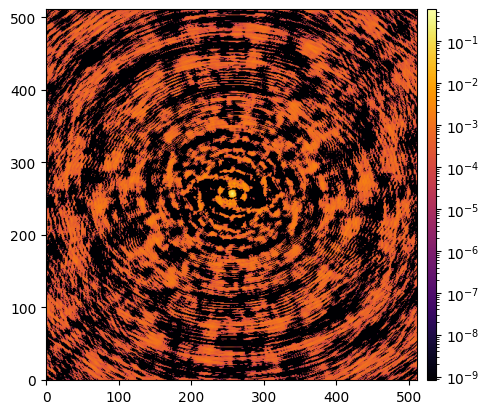

In [3]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(256,256), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [4]:
def fft_kernel_2d(kernel, grid, model):
    kernel = kernel.copy()
    fac = grid.factor // model.grid.factor
    if fac > 1:
        kernel = downsample(kernel, fac)
    if model.grid.space != grid.space:
        kernel = map_array(kernel, 2*grid, 2*model.grid.update(center=(0,0)))
    kernel = shift_kernel(kernel)
    grid_l = model.grid.update(space=tuple(s*2 for s in model.grid.space))
    fft_kernel = fft_fun(grid_l)(kernel)
    return fft_kernel


def shift_kernel(kernel):
    shifted_kernel = np.roll(kernel, -kernel.shape[0]//2, axis=0)
    shifted_kernel = np.roll(shifted_kernel, -kernel.shape[1]//2, axis=1)
    return shifted_kernel


def fft_convolve_2d(fft_kernel, grid):
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))

    fft_l = fft_fun(grid_l)
    ifft_l = ifft_fun(grid_l)
    fft_kernel = jnp.array(fft_kernel)
    padding = grid.shp // 2

    def conv(x):
        res = jnp.pad(x, (2*(padding[0],), 2*(padding[1],)))
        res = ifft_l(fft_kernel * fft_l(res)).real
        res = jax_slice(res, padding, padding + grid.shp)
        return res
    
    return conv


def fft_fun(grid):
    check_type(grid, SignalGrid)
    dvol = grid.dis.prod()
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(grid):
    check_type(grid, SignalGrid)
    dvol = 1. / (grid.shp * grid.dis).prod()
    npix = grid.size
    return lambda x: dvol * npix * jnp.fft.ifftn(x)



class SignalModel(jft.Model):

    def __init__(self, grid, i0, prefix='sm'):
        self.grid = grid
        self.i0 = i0
        self.prefix = prefix
        super().__init__(domain=self.i0.domain, init=self.i0.init)

    def __call__(self, x, *, out_grid=None):
        res = jnp.exp(self.i0(x))
        if out_grid:
            return map_array(res, self.grid, out_grid)
        return res
    


class ComponentModel(jft.Model):

    def __init__(self, grid, background, *components):
        self.grid = grid
        self.models = (background, ) + components
        self.background = background
        self.components = components

        super().__init__(
            domain = jft.Vector(domain_tree(self.models)), 
            init = model_init(self.models),
        )

    def __call__(self, x, *, out_grid=None):
        out_grid = out_grid if out_grid else self.grid
        res = jnp.zeros(out_grid.shape)
        for m in self.models:
            res += m(x, out_grid=out_grid)
        return res



class LowResolutionResponse(jft.Model):
    
    def __init__(self, model, kernel):
        self.model = model
        self.grid_low = model.background.grid
        self.fft_kernel_low = fft_kernel_2d(kernel, self.model.grid, self.model.background)
        
        super().__init__(
            domain = self.model.domain, 
            init = self.model.init,
        )

    def __call__(self, x):
        sig_low = self.model(x, out_grid=self.grid_low)
        rsp_low = fft_convolve_2d(self.fft_kernel_low, self.grid_low)(sig_low)
        return rsp_low
    


class HighResolutionResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid
        self.fft_kernel = fft_kernel_2d(kernel, self.grid, self.model)

        super().__init__(
            domain = self.model.domain, 
            init = self.model.init,
        )

    def __call__(self, x):
        sig = self.model(x)
        rsp = fft_convolve_2d(self.fft_kernel, self.model.grid)(sig)
        return rsp  



class MultiResolutionResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.background = model.background
        self.components = model.components
        self.grid = model.grid
        self.factor = self.grid.factor // self.background.grid.factor

        self.fft_kernels = []
        for mdl in model.models:
            self.fft_kernels.append(fft_kernel_2d(kernel, self.grid, mdl))

        super().__init__(
            domain = self.model.domain, 
            init = self.model.init,
        )

    def __call__(self, x):
        sig_low = self.model(x, out_grid=self.background.grid)
        rsp_low = fft_convolve_2d(self.fft_kernels[0], self.background.grid)(sig_low)

        for c_mdl, c_ker in zip(self.components, self.fft_kernels[1:]):
            c_rsp_high = fft_convolve_2d(c_ker, c_mdl.grid)(c_mdl(x))

        rsp = jnp.stack((rsp_low, c_rsp_high), axis=0)

        return rsp



class MultiScaleResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.background = model.background
        self.components = model.components
        self.grid = model.grid
        self.factor = self.grid.factor // self.background.grid.factor

        self.fft_kernels = []
        for mdl in model.models:
            self.fft_kernels.append(fft_kernel_2d(kernel, self.grid, mdl))

        super().__init__(
            domain = self.model.domain, 
            init = self.model.init,
        )

    def __call__(self, x):
        sig_low = self.model(x, out_grid=self.background.grid)

        rsp_low = fft_convolve_2d(self.fft_kernels[0], self.background.grid)(sig_low)
        rsp_high = upsample(rsp_low, self.factor)

        for c_mdl, c_ker in zip(self.components, self.fft_kernels[1:]):
            c_rsp_high = fft_convolve_2d(c_ker, c_mdl.grid)(c_mdl(x))

            c_grd_low = c_mdl.grid.update(factor=1)
            c_ker_low = downsample(c_ker, self.factor)
            c_rsp_low = fft_convolve_2d(c_ker_low, c_grd_low)(c_mdl(x, out_grid=c_grd_low))

            rsp_slc = map_array(rsp_low, self.background.grid, c_mdl.grid.update(factor=1))
            rsp_sub = rsp_slc - c_rsp_low
            rsp_add = upsample(rsp_sub, self.factor) + c_rsp_high
            rsp_val = map_array(rsp_add, c_mdl.grid, self.grid)

            c_msk = map_array(np.ones(c_rsp_high.shape), c_mdl.grid, self.grid)
            rsp_high = rsp_high * (1 - c_msk).clip(0, 1) + rsp_val

        return rsp_high
    

SignalGrid(space=(128, 128), center=(0, 0), factor=1, distances=(0.000136353847812057, 0.000136353847812057))
SignalGrid(space=(64, 64), center=(0, 0), factor=2, distances=(0.000136353847812057, 0.000136353847812057))
SignalGrid(space=(128, 128), center=(0, 0), factor=2, distances=(0.000136353847812057, 0.000136353847812057))


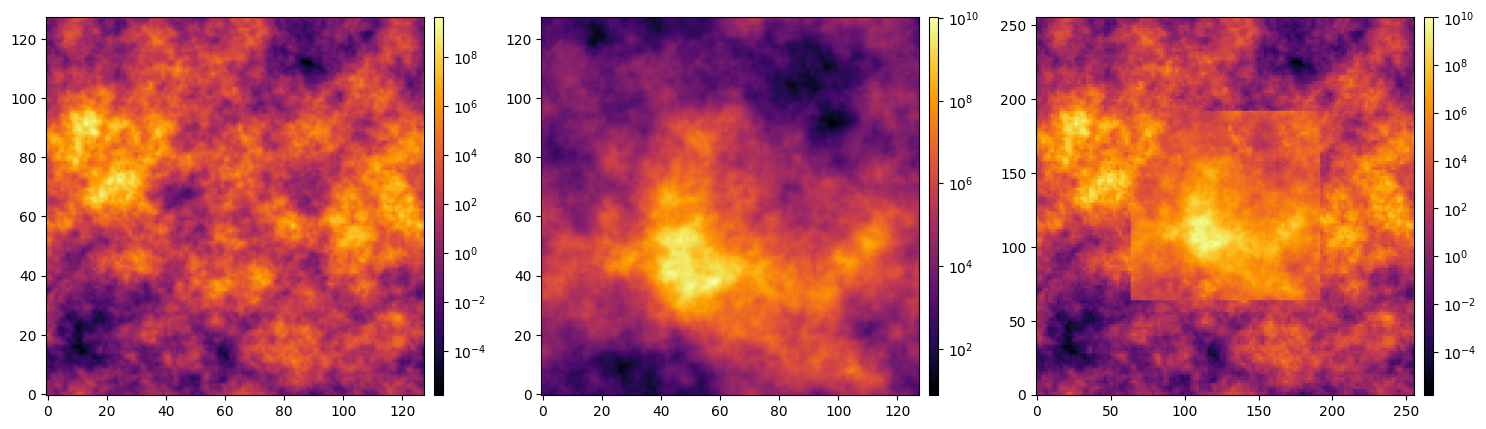

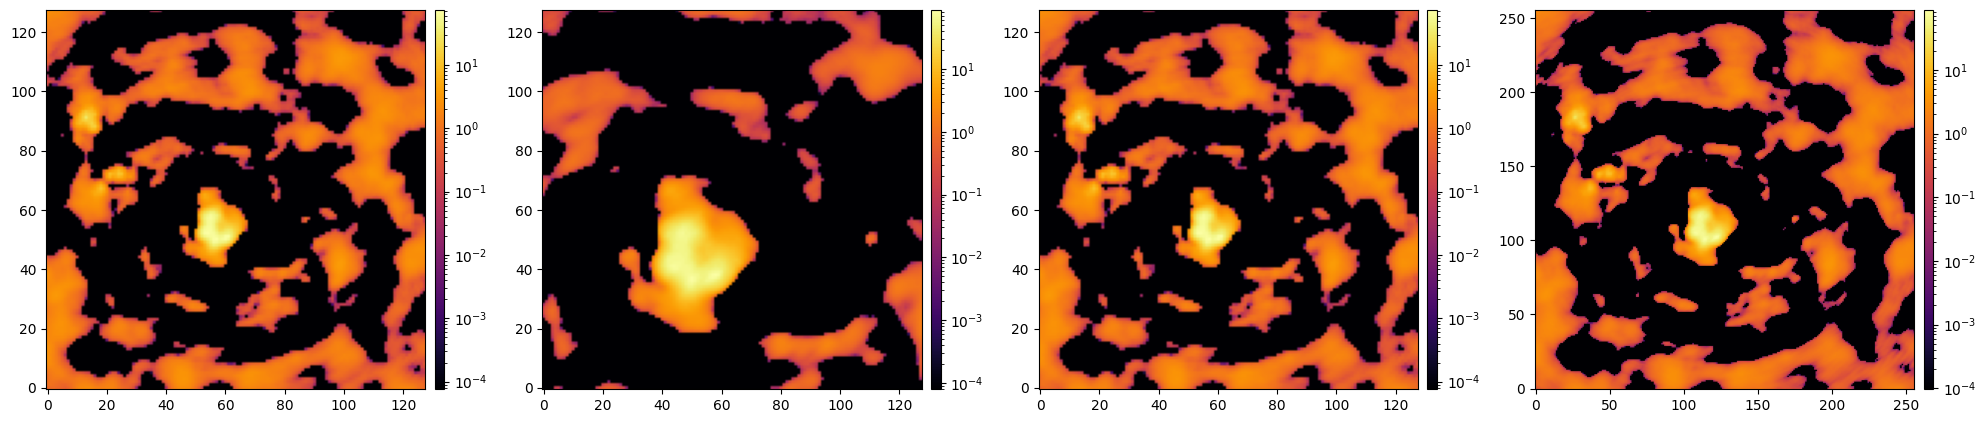

In [5]:
space = SignalSpace.build(shape=(128, 128), fov=('1deg', '1deg'))

bg_grid = SignalGrid(space=(128,128), center=(0,0), factor=1, distances=space.distances)
print(bg_grid)

bg, pw = correlated_field_model(
    prefix='bg ',
    shape=bg_grid.shape,
    distances=bg_grid.distances,
    offset_mean=5,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
sig_bg = SignalModel(bg_grid, bg, prefix='bg')


t0_grid = SignalGrid(space=(64, 64), center=(0,0), factor=2, distances=space.distances)
print(t0_grid)
t0, pw = correlated_field_model(
    prefix='t0 ',
    shape=t0_grid.shape,
    distances=t0_grid.distances,
    offset_mean=10,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
sig_t0 = SignalModel(t0_grid, t0, prefix='t0')


grid = SignalGrid(space=bg_grid.space, center=(0,0), factor=2, distances=space.distances)
print(grid)

signal = ComponentModel(grid, sig_bg, sig_t0)

ms_response = MultiResolutionResponse(signal, kernel)

lr_response = LowResolutionResponse(signal, kernel)

hr_response = HighResolutionResponse(signal, kernel)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays([sig_bg(prior_xi), sig_t0(prior_xi), signal(prior_xi)], rows=1, norm='log')

plot_arrays([ms_response(prior_xi)[0], ms_response(prior_xi)[1], lr_response(prior_xi), hr_response(prior_xi)], rows=1, norm='log')

(2, 128, 128)


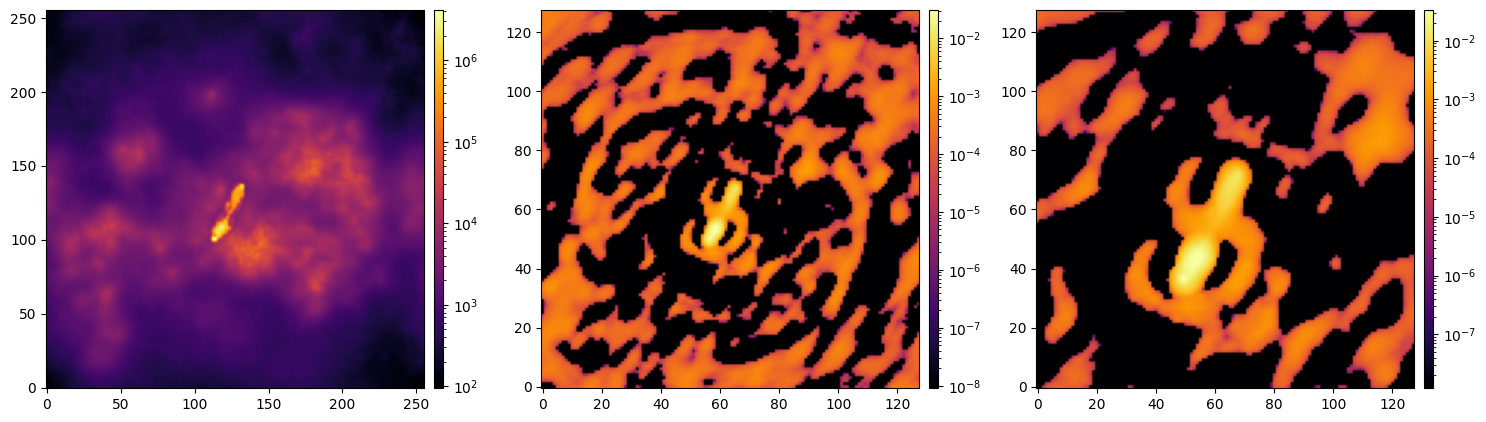

In [ ]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_t0 = optim_cfg.instantiate_sec('sky_o0.3')

with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = samples.mean(sky_bg)
rec_t0 = map_signal(samples.mean(sky_t0), sky_t0.space, sky_bg.space)

rec = rec_bg + rec_t0
rec = downsample(rec, 2)
rec_t0 = map_array(rec, grid, t0_grid)

fft_kernel = fft_kernel_2d(kernel, grid, signal)
truth = fft_convolve_2d(fft_kernel, grid)(rec)

rec_low = downsample(rec, 2)
fft_kernel_low = fft_kernel_2d(kernel, grid, signal.background)
truth_low = fft_convolve_2d(fft_kernel_low, bg_grid)(rec_low)

fft_kernel_t0 = fft_kernel_2d(kernel, grid, signal.components[0])
truth_t0 = fft_convolve_2d(fft_kernel_t0, t0_grid)(rec_t0)

truth = np.stack((truth_low, truth_t0), axis=0)
print(truth.shape)

n_std = 1e-4
noise = n_std * jax.random.normal(key, truth.shape)
data = truth + noise

plot_arrays([rec, truth[0], truth[1]], rows=1, norm='log')

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.5416e+05
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 100
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     8.7±     3.8, avg:   +0.096±    0.13, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     8.7±    0.43, avg:     -3.0±   0.073, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:     3.0±     1.1, avg:     -1.7±    0.33, #dof:      1'
bg xi                   :: 'reduced χ²:    0.98±  0.0025, avg: -0.00014±   0.011, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.49±    0.45, avg:   +0.091±    0.69, #dof:      1'
t0 fluctuations         :: 'reduced χ²: 1.5e+01±     8.1, avg:     +3.7±     1.1, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:    0.15±    0.13, avg:    -0.32±    0.21, #dof:      1'
t0 xi                   :: 'reduced χ²:    0.49±   0.032, avg:  -0.0002±  0.0023, #dof:  16384'
t0 zeromode             :: '

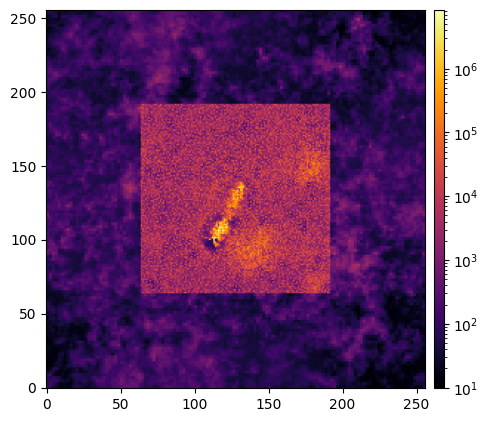

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+7.1062e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 100
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     3.4±    0.23, avg:   +0.074±   0.084, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²: 3.2e+01± 1.2e+01, avg:     -5.6±     1.1, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.6e+01±     5.3, avg:     -4.0±    0.66, #dof:      1'
bg xi                   :: 'reduced χ²:    0.99±  0.0025, avg: -0.00029±  0.0052, #dof:  16384'
bg zeromode             :: 'reduced χ²:   0.048±  0.0062, avg:    -0.22±   0.014, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     6.6±     3.5, avg:     -2.5±     0.7, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     4.1±     1.6, avg:     -2.0±    0.39, #dof:      1'
t0 xi                   :: 'reduced χ²:    0.97±  0.0098, avg: -0.00076±   0.014, #dof:  16384'
t

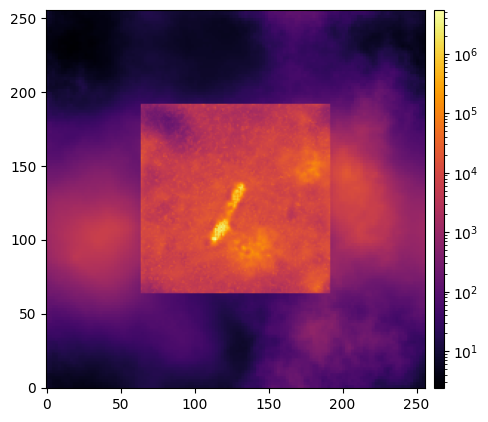

OPTIMIZE_KL: Starting 0003
OPTIMIZE_KL: Iteration 0003 ⛰:+3.4880e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 46
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±   0.012, avg:   -0.047±  0.0085, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²: 2.9e+01±     1.5, avg:     -5.4±    0.14, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.8e+01±     9.5, avg:     -4.0±     1.2, #dof:      1'
bg xi                   :: 'reduced χ²:     1.0±  0.0041, avg: -0.00029±  0.0037, #dof:  16384'
bg zeromode             :: 'reduced χ²:     0.3±    0.29, avg:    -0.35±    0.42, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     2.4±     1.4, avg:     -1.5±    0.49, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     6.7±    0.75, avg:     -2.6±    0.15, #dof:      1'
t0 xi                   :: 'reduced χ²:    0.96±   0.006, avg: -0.00074±  0.0051, #dof:  16384'
t0 zeromode             :: 're

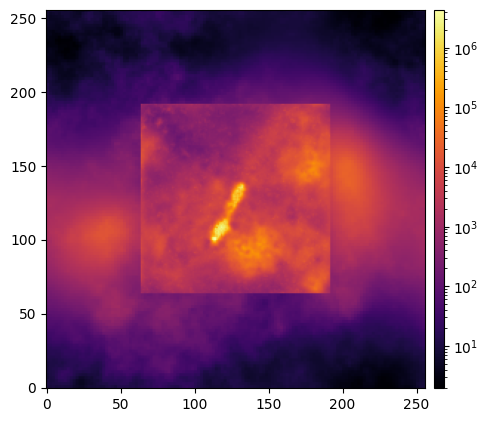

OPTIMIZE_KL: Starting 0004
OPTIMIZE_KL: Iteration 0004 ⛰:+3.4760e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 8
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±   0.004, avg:   -0.043±  0.0097, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   3e+01±     7.8, avg:     -5.4±    0.72, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.6e+01±    0.98, avg:     -4.0±    0.12, #dof:      1'
bg xi                   :: 'reduced χ²:     1.0±  0.0056, avg: -0.00029±  0.0099, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.93±    0.75, avg:    -0.35±     0.9, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     2.6±     2.2, avg:     -1.4±    0.81, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     7.2±     1.0, avg:     -2.7±    0.19, #dof:      1'
t0 xi                   :: 'reduced χ²:     1.0±   0.014, avg: -0.00072±   0.004, #dof:  16384'
t0 zeromode             :: 'red

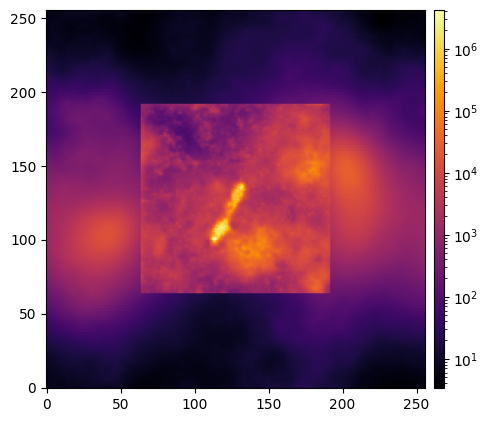

OPTIMIZE_KL: Starting 0005
OPTIMIZE_KL: Iteration 0005 ⛰:+3.4253e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 18
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±  0.0016, avg:   -0.048±  0.0066, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   3e+01±     8.6, avg:     -5.4±     0.8, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.4e+01±     2.2, avg:     -3.7±    0.29, #dof:      1'
bg xi                   :: 'reduced χ²:     1.0±   0.018, avg: -0.00029±   0.004, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.31±    0.32, avg:    -0.32±    0.45, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     2.3±     1.4, avg:     -1.4±    0.49, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     8.1±    0.47, avg:     -2.8±   0.083, #dof:      1'
t0 xi                   :: 'reduced χ²:     1.0±   0.015, avg: -0.00065±    0.01, #dof:  16384'
t0 zeromode             :: 're

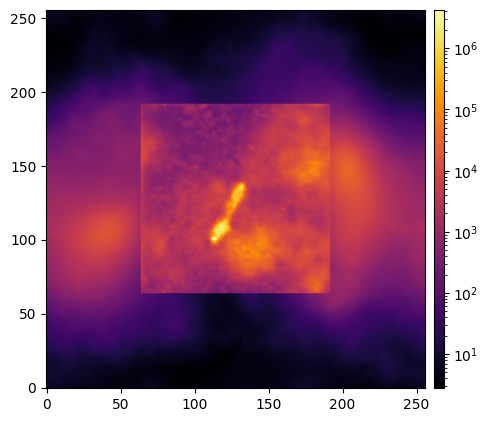

OPTIMIZE_KL: Starting 0006
OPTIMIZE_KL: Iteration 0006 ⛰:+3.4199e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 15
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±  0.0029, avg:   -0.047±  0.0061, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²: 3.1e+01±     8.2, avg:     -5.5±    0.73, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.5e+01±     4.8, avg:     -3.9±    0.61, #dof:      1'
bg xi                   :: 'reduced χ²:     1.0±  0.0054, avg:  -0.0003±  0.0087, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.57±    0.59, avg:    -0.35±    0.66, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     2.1±     1.4, avg:     -1.3±    0.52, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     8.3±    0.65, avg:     -2.9±    0.11, #dof:      1'
t0 xi                   :: 'reduced χ²:    0.99±  0.0051, avg: -0.00065±  0.0075, #dof:  16384'
t0 zeromode             :: 're

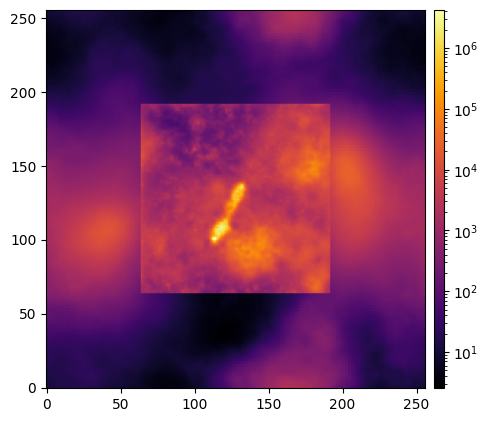

OPTIMIZE_KL: Starting 0007
OPTIMIZE_KL: Iteration 0007 ⛰:+4.4196e+04
OPTIMIZE_KL: Linear sampling status (1000, 1000)
OPTIMIZE_KL: #(KL minimization steps) 43
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.7±    0.17, avg:   +0.004±   0.014, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²: 2.9e+01±     7.4, avg:     -5.4±    0.69, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 1.4e+01±     6.1, avg:     -3.6±    0.84, #dof:      1'
bg xi                   :: 'reduced χ²:     1.0±  0.0076, avg: -0.00028±  0.0032, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.77±    0.58, avg:    -0.36±     0.8, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     7.0±     5.3, avg:     -2.4±     1.1, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     8.4±     1.6, avg:     -2.9±    0.28, #dof:      1'
t0 xi                   :: 'reduced χ²:     1.0±  0.0051, avg: -0.00059±  0.0031, #dof:  16384'
t0 zeromode             :: 're

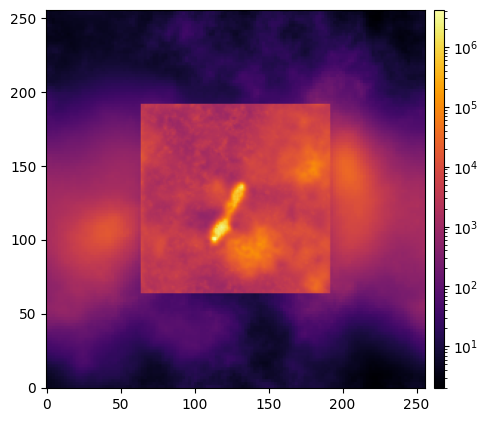

OPTIMIZE_KL: Starting 0008


: 

In [55]:
lh_dct = dict(
    data = data,
    model = ms_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=10,
    n_samples=2,
    draw_linear_kwargs=dict(
        cg_kwargs=dict(
            maxiter=1000,
            name=None,
        ),
    ),
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            maxiter=100,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)